# Sales and Product Data Analysis


## About the Data
This dataset contains sales transactions for an expanding retail/e-commerce business. 
- `sales_transactions.csv`: Contains individual order details, quantities, and customer information.
- `product_master.csv`: Contains product details, categories, and financial pricing metrics.


## Import All CSV Files
We will import pandas and specifically load the two CSV files found in our project directory.


In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a beautiful aesthetic for charts
sns.set_theme(style="whitegrid")

# Load the datasets
sales = pd.read_csv('sales_transactions.csv')
products = pd.read_csv('product_master.csv')


## Basic Inspection
Let's look at the size of our datasets and examine a few sample rows to understand the structure.


In [113]:
print(f"Sales table rows: {len(sales)}")
print(f"Products table rows: {len(products)}")

print("\nSales Data Preview:")
display(sales.head())

print("\nProducts Data Preview:")
display(products.head())


Sales table rows: 1000
Products table rows: 30

Sales Data Preview:


,order_id,order_date,customer_id,customer_name,city,state,region,product_id,quantity,discount_pct,sales_channel,payment_method
0,ORD-00001,23-12-2024,C018,Meera Rao,New York,New York,East,P026,6,0%,Online,UPI
1,ORD-00002,05-05-2023,C117,Diya Nair,San Francisco,California,West,P029,1,20%,Online,Credit Card
2,ORD-00003,19-01-2024,C076,Anika Nair,Boston,Massachusetts,East,P019,7,0%,Online,Credit Card
3,ORD-00004,18-12-2023,C053,Rohan Bansal,Seattle,Washington,West,P029,9,0%,Wholesale,Cash
4,ORD-00005,11-10-2025,C055,Tanvi Patel,Boston,Massachusetts,East,P025,4,5%,Retail,UPI



Products Data Preview:


,product_id,product_name,category,subcategory,brand,unit_price,unit_cost
0,P001,Business Laptop 14,Electronics,Computers,NovaTech,920.0,690.0
1,P002,Wireless Mouse,Electronics,Accessories,NovaTech,24.0,11.0
2,P003,Mechanical Keyboard,Electronics,Accessories,TypePro,78.0,38.0
3,P004,27 inch Monitor,Electronics,Monitors,VisionMax,210.0,145.0
4,P005,USB C Dock,Electronics,Accessories,LinkHub,95.0,58.0


In [114]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        1000 non-null   str  
 1   order_date      1000 non-null   str  
 2   customer_id     1000 non-null   str  
 3   customer_name   1000 non-null   str  
 4   city            1000 non-null   str  
 5   state           1000 non-null   str  
 6   region          1000 non-null   str  
 7   product_id      1000 non-null   str  
 8   quantity        1000 non-null   int64
 9   discount_pct    1000 non-null   str  
 10  sales_channel   1000 non-null   str  
 11  payment_method  1000 non-null   str  
dtypes: int64(1), str(11)
memory usage: 93.9 KB


## Data Cleaning
We need to ensure our data has the correct format for analysis:
1. The `order_date` column should be a true datetime object instead of text.
2. The `discount_pct` column needs to be converted from a string (like "10%") into a decimal float (like 0.10) for math calculations.


In [115]:
# Convert date column to datetime
sales['order_date'] = pd.to_datetime(sales['order_date'], format='mixed')

# Clean discount percentage (remove '%' and convert to float)
sales['discount_pct']=sales['discount_pct'].str.replace('%','').astype('float')/100

print("Data cleaning complete. Here are the updated data types for sales:")
print(sales.dtypes)


Data cleaning complete. Here are the updated data types for sales:
order_id                     str
order_date        datetime64[us]
customer_id                  str
customer_name                str
city                         str
state                        str
region                       str
product_id                   str
quantity                   int64
discount_pct             float64
sales_channel                str
payment_method               str
dtype: object


## Feature Engineering
Let's extract the month and year from the order date. This will be very useful later when we want to see trends over time!


In [116]:
sales['order_month'] = sales['order_date'].dt.strftime('%Y-%m')

# View the new column
sales[['order_date', 'order_month']].head()


,order_date,order_month
0,2024-12-23,2024-12
1,2023-05-05,2023-05
2,2024-01-19,2024-01
3,2023-12-18,2023-12
4,2025-11-10,2025-11


## Merges and Master Table
Right now, our sales data only has a `product_id`, but it doesn't tell us the product's name, category, or cost. 
We need to **merge** the tables:
- **Left Table**: `sales`
- **Right Table**: `products`
- **Key**: We will join them using the `product_id` which exists in both tables.

This gives us a master table with all information in one place! After that, we calculate accurate revenue and profit.


In [117]:
# Merge the data
master_df = sales.merge(products, on='product_id', how='left')

# Calculate Revenue: (Quantity * Unit Price) - Discount
master_df['revenue'] = master_df['quantity'] * master_df['unit_price'] * (1 - master_df['discount_pct'])

# Calculate Profit: Revenue - Total Cost
master_df['profit'] = master_df['revenue'] - (master_df['quantity'] * master_df['unit_cost'])

print(f"Master table created with {len(master_df)} rows and {len(master_df.columns)} columns.")


Master table created with 1000 rows and 21 columns.


## KPI Calculation
Let's calculate some high-level Key Performance Indicators (KPIs) for the business.


In [118]:
total_revenue = master_df['revenue'].sum()
total_profit = master_df['profit'].sum()
total_orders = master_df['order_id'].nunique()
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")


Total Revenue: $254,240.75
Total Profit: $81,094.35
Total Orders: 1,000
Average Order Value: $254.24


## Charts
Finally, let's visualize our data with Python! Visualizations help us spot trends and compare groups easily.


C:\Users\anand\AppData\Local\Temp\ipykernel_11524\3628088654.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_rev, x='category', y='revenue', palette='viridis')


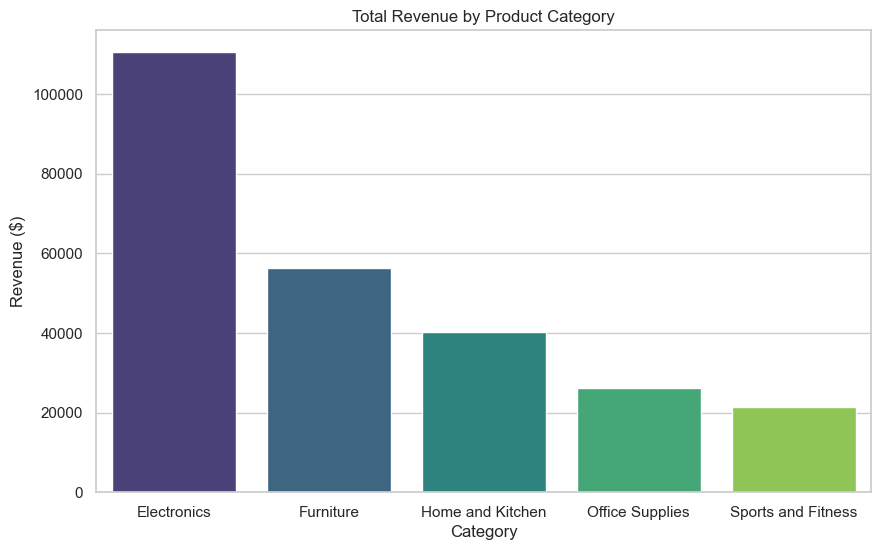

In [119]:
# 1. Bar Chart: Revenue by Category
plt.figure(figsize=(10, 6))
cat_rev = master_df.groupby('category')['revenue'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=cat_rev, x='category', y='revenue', palette='viridis')
plt.title('Total Revenue by Product Category')
plt.xlabel('Category')
plt.ylabel('Revenue ($)')
plt.show()


**Interpretation**: This bar chart easily shows us which product categories bring in the most money for the business.


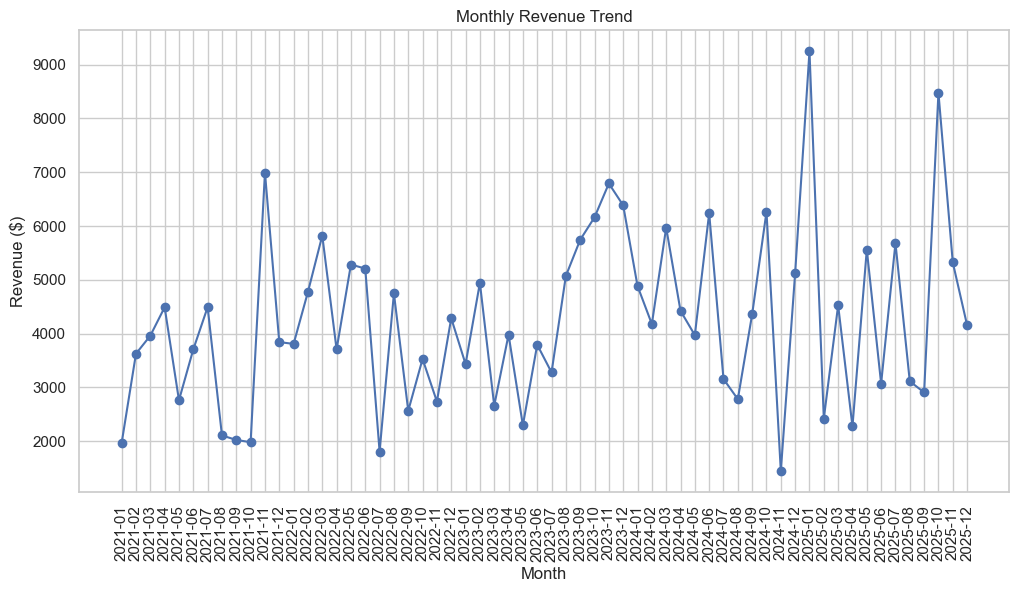

In [120]:
# 2. Line Chart: Monthly Revenue Trend
plt.figure(figsize=(12, 6))
monthly_rev = master_df.groupby('order_month')['revenue'].sum()
# Convert period index to string for plotting back on a simple line chart
monthly_rev.index = monthly_rev.index.astype(str)
plt.plot(monthly_rev.index, monthly_rev.values, marker='o', linestyle='-', color='b')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=90)
plt.show()


**Interpretation**: The line chart highlights the peaks and valleys in our sales over time. We can spot our strongest and weakest months!


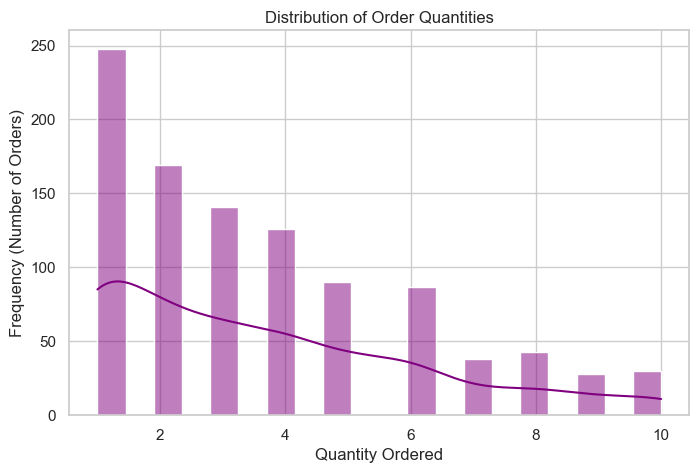

In [121]:
# 3. Histogram: Distribution of Order Quantities
plt.figure(figsize=(8, 5))
sns.histplot(master_df['quantity'], bins=20, kde=True, color='purple')
plt.title('Distribution of Order Quantities')
plt.xlabel('Quantity Ordered')
plt.ylabel('Frequency (Number of Orders)')
plt.show()


**Interpretation**: The histogram tells us about typical customer behavior. It shows whether most people buy 1 item at a time, or if large bulk orders are common.


## Final Summary
In this notebook, we analyzed a dataset containing sales transactions and product details for a retail business. 
- We cleanly imported two separate CSV files and successfully merged them together using their shared `product_id`.
- We calculated that the business has healthy total revenues and generated KPIs.
- Our charts revealed which product categories perform the best and how revenue shifts from month to month.
Data analysis allows us to turn raw numbers into actionable business insights!
